# From Factors to Actors: a Rock-Paper-Scissors example

Statistical analysis works with **factors** - variables, and the associations between them. Agent-based modeling works with **actors** - the individuals whose decisions, repeated many times, generate the variables we later put in a table.

This notebook walks through both sides of that distinction, using a small Rock-Paper-Scissors tournament:

1. We start where a data scientist usually starts: a table, and a regression.
2. We ask what the regression can and cannot tell us about how that table came to be.
3. We build the actors - first as simple dictionaries, then as objects with a proper agent architecture, following Axtell (2000).

# Part 0 - A table, and a regression

This is the kind of data you are usually handed: one row per player, with two demographic covariates (`age`, `sex`) and a `final_points` column - the outcome of a completed Rock-Paper-Scissors tournament:

In [1]:
import pandas as pd
from sklearn.linear_model import LinearRegression

observed = pd.read_csv('https://github.com/DACSS-Complexity/s3_computational_social_science_and_complexity/raw/main/rps_players.csv')
observed

,player,age,sex,final_points
0,Ava,22,F,37
1,Ben,45,M,75
2,Cleo,29,F,31
3,Dan,51,M,31
4,Eva,34,F,27
5,Finn,19,M,56
6,Gia,60,F,48
7,Hugo,38,M,69


Having these data available, with clear Y (*final points*) and some likely covariates, you might be tempted to propose a regression, our next step.

## Regressing `final_points` on `age` and `sex`

We turn `sex` into a 0/1 column (`sex_M`, with `F` as the reference level) and fit a linear regression.

In [2]:
X = pd.get_dummies(observed[['sex']], drop_first=True, dtype=int)
X['age'] = observed['age']
y = observed['final_points']

model = LinearRegression().fit(X, y)

pd.DataFrame({
    'term': ['Intercept'] + list(X.columns),
    'coefficient': [model.intercept_] + list(model.coef_)
})

,term,coefficient
0,Intercept,32.301924
1,sex_M,21.809761
2,age,0.095119


In [3]:
print(f'R-squared: {model.score(X, y):.3f}')

R-squared: 0.415


This regression did its job. It describes how `final_points` co-varies with `age` and `sex` in this particular table.

# Part 1 - What the table does not show

`final_points` is not a fact about a player. It is a **generated result**: the output of many rounds of a game, played against different opponents, decided move by move.

None of that process survives into the table. The dataframe keeps the *outcome* of the dynamics and throws away the dynamics themselves - who played whom, in what order, what each of them chose, round after round. A regression on `final_points` can only ever describe the leftover residue of that process; it has no way to reconstruct, confirm, or rule out any particular story about how the process actually worked.

To see the dynamics, we have to stop summarizing players as rows in a table and start representing them as **actors** who make a decision every time they play. That is not a trivial job, but this notebook will help you take the first steps.

# Part 2 - Proto-agents, as dictionaries

The simplest way to represent an agent in Python is a dictionary: a bundle of attributes that can change over time.

These are two dicts, each representing an agent:

In [4]:
ava={'name': 'Ava', 'age': 22, 'sex': 'F', 'score': 0, 'strategy': None}
ben={'name': 'Ben', 'age': 45, 'sex': 'M', 'score': 0, 'strategy': None}

The game rules can be represented like this:

In [5]:
strategies = ['Rock', 'Paper', 'Scissors']

payoff = {
    ('Rock', 'Paper'): (0, 1),
    ('Paper', 'Rock'): (1, 0),
    ('Rock', 'Scissors'): (1, 0),
    ('Scissors', 'Rock'): (0, 1),
    ('Paper', 'Scissors'): (0, 1),
    ('Scissors', 'Paper'): (1, 0),
    ('Rock', 'Rock'): (0, 0),
    ('Paper', 'Paper'): (0, 0),
    ('Scissors', 'Scissors'): (0, 0)
}

## Decision-making process

The decision rule is as plain as it can be, pick a move at random:

In [6]:
from random import choice

#simplest strategy: choose randomly
choice(strategies),choice(strategies),choice(strategies),choice(strategies),choice(strategies)

('Scissors', 'Scissors', 'Rock', 'Rock', 'Rock')

**Each agent decides a strategy:**

In [7]:
# not really deciding:

ava['strategy'] = choice(strategies)
ben['strategy'] = choice(strategies)

**Decisions made:**

In [8]:
ava['strategy'], ben['strategy']

('Rock', 'Scissors')

**Social result of the individual decisions:**

In [9]:
result = payoff[ava['strategy'], ben['strategy']]
result

(1, 0)

**Each agent's score updates:**

In [10]:
ava['score'] += result[0]
ben['score'] += result[1]

Updated players!

In [11]:
ava

{'name': 'Ava', 'age': 22, 'sex': 'F', 'score': 1, 'strategy': 'Rock'}

In [12]:
ben

{'name': 'Ben', 'age': 45, 'sex': 'M', 'score': 0, 'strategy': 'Scissors'}

## Generating a final score, and comparing

One game is not a tournament. We let these same two agents play a series of rounds against each other, always with the same rule: `choice(strategies)`, nothing else. Then we compare their **generated** final scores - to each other, not to `age` or `sex`, because age and sex were never part of the mechanism.

In [13]:
# reset scores, keep identities
Players = [{'name': 'Ava', 'age': 22, 'sex': 'F', 'score': 0, 'strategy': None},
           {'name': 'Ben', 'age': 45, 'sex': 'M', 'score': 0, 'strategy': None}]

for aRound in range(1, 21):
    Players[0]['strategy'] = choice(strategies)
    Players[1]['strategy'] = choice(strategies)
    result = payoff[Players[0]['strategy'], Players[1]['strategy']]
    Players[0]['score'] += result[0]
    Players[1]['score'] += result[1]

Players

[{'name': 'Ava', 'age': 22, 'sex': 'F', 'score': 9, 'strategy': 'Rock'},
 {'name': 'Ben', 'age': 45, 'sex': 'M', 'score': 4, 'strategy': 'Scissors'}]

Something familiar:

In [14]:
pd.DataFrame(Players)[['name', 'age', 'sex', 'score']]

,name,age,sex,score
0,Ava,22,F,9
1,Ben,45,M,4


Ava and Ben ended up with different scores after 20 rounds. Nothing in the mechanism that produced that difference had anything to do with being 22 versus 45, or `F` versus `M` - it was `choice(strategies)`, called independently each time. `age` and `sex` are just labels riding along on the dictionary; they play no causal role. Keep that firmly in mind for Part 3.

# Part 3 - Scaling up, and comparing against Part 0

We now build a proto-agent for each of the eight players in `observed`, carrying their real `name`, `age` and `sex` forward as labels - and run a full round-robin tournament with the exact same rule as Part 2: `choice(strategies)`, independent of every attribute.

In [15]:
import itertools

society = [{'name': row.player, 'age': int(row.age), 'sex': row.sex, 'score': 0, 'strategy': None}
           for row in observed.itertuples(index=False)]
society

[{'name': 'Ava', 'age': 22, 'sex': 'F', 'score': 0, 'strategy': None},
 {'name': 'Ben', 'age': 45, 'sex': 'M', 'score': 0, 'strategy': None},
 {'name': 'Cleo', 'age': 29, 'sex': 'F', 'score': 0, 'strategy': None},
 {'name': 'Dan', 'age': 51, 'sex': 'M', 'score': 0, 'strategy': None},
 {'name': 'Eva', 'age': 34, 'sex': 'F', 'score': 0, 'strategy': None},
 {'name': 'Finn', 'age': 19, 'sex': 'M', 'score': 0, 'strategy': None},
 {'name': 'Gia', 'age': 60, 'sex': 'F', 'score': 0, 'strategy': None},
 {'name': 'Hugo', 'age': 38, 'sex': 'M', 'score': 0, 'strategy': None}]

We could force replicability like this:

In [16]:
from random import Random
tournament_rng = Random(42)

Then,

In [17]:
for player1, player2 in itertools.combinations(society, 2):
    player1['strategy'] = tournament_rng.choice(strategies)
    player2['strategy'] = tournament_rng.choice(strategies)
    result = payoff[player1['strategy'], player2['strategy']]
    player1['score'] += result[0]
    player2['score'] += result[1]

generated = pd.DataFrame(society)[['name', 'age', 'sex', 'score']]
generated

,name,age,sex,score
0,Ava,22,F,2
1,Ben,45,M,3
2,Cleo,29,F,2
3,Dan,51,M,2
4,Eva,34,F,1
5,Finn,19,M,3
6,Gia,60,F,2
7,Hugo,38,M,4


Imagine the last result was a one-weekend tournament. What if they played 20 weekends a year? We keep the same `tournament_rng` and the same `society` - nothing is reset - so this really is 19 *more* weekends stacked on top of the one just played, not a fresh restart:

In [18]:
for aRound in range(19):
    for player1, player2 in itertools.combinations(society, 2):
        player1['strategy'] = tournament_rng.choice(strategies)
        player2['strategy'] = tournament_rng.choice(strategies)
        result = payoff[player1['strategy'], player2['strategy']]
        player1['score'] += result[0]
        player2['score'] += result[1]

generated = pd.DataFrame(society)[['name', 'age', 'sex', 'score']]
generated

,name,age,sex,score
0,Ava,22,F,53
1,Ben,45,M,39
2,Cleo,29,F,50
3,Dan,51,M,45
4,Eva,34,F,42
5,Finn,19,M,49
6,Gia,60,F,42
7,Hugo,38,M,52


## Does a regression on the *generated* scores find anything?

We run the identical regression from Part 0 - `score` on `age` and `sex` - but now on data we generated ourselves, knowing for a fact that `age` and `sex` had zero influence on the mechanism that produced it.

In [19]:
Xg = pd.get_dummies(generated[['sex']], drop_first=True, dtype=int)
Xg['age'] = generated['age']
yg = generated['score']

model_g = LinearRegression().fit(Xg, yg)

pd.DataFrame({
    'term': ['Intercept'] + list(Xg.columns),
    'coefficient': [model_g.intercept_] + list(model_g.coef_)
})

,term,coefficient
0,Intercept,55.376648
1,sex_M,-0.024047
2,age,-0.237976


In [20]:
print(f'R-squared: {model_g.score(Xg, yg):.3f}')

R-squared: 0.421


## The point

Whatever coefficients come out of the cell above are pure artifacts of randomness with a small sample - we *know* that, because we built the mechanism and `age`/`sex` never entered it. Yet the regression procedure does not know that; it will report *some* coefficient regardless, and nothing about the regression output by itself would tell you it is meaningless here.

That is exactly the limitation from Part 0. The regression on `observed` (the original table) and the regression on `generated` (our table, with a mechanism we fully control and know to be independent of age/sex) are computed by the exact same procedure and can look similarly "informative." The difference between a real effect and a coincidental one is not visible in the regression output - it depends entirely on the generating mechanism, which the table never records. This is the "factors versus actors" point from Macy and Willer (2002): a table of factors can be produced by more than one story about the actors behind it, and regression alone cannot adjudicate between them.

## `generated` is one draw from a sea of possible tournaments

There is one more thing the `generated` table hides, on top of everything Part 1 already flagged: it is not *the* outcome of this mechanism - it is *a single draw* from everything this mechanism could have produced. Nothing about the agents or the rules changes if we replay the exact same 20-round, 8-player tournament with a different random seed - only the particular sequence of moves does. From an emergent-systems point of view, that is the whole idea: a rule-based process does not generate one fixed table, it generates a *distribution* of possible tables, and any single run - including `observed` itself, if it came from a process like this one - is just one sample out of that sea of possible agent interactions.

We replay the identical tournament eight times, changing only the seed:

In [21]:
def run_generated_tournament(seed, rounds=20):
    replay_society = [{'name': row.player, 'age': int(row.age), 'sex': row.sex, 'score': 0, 'strategy': None}
                       for row in observed.itertuples(index=False)]
    replay_rng = Random(seed)
    for aRound in range(rounds):
        for player1, player2 in itertools.combinations(replay_society, 2):
            player1['strategy'] = replay_rng.choice(strategies)
            player2['strategy'] = replay_rng.choice(strategies)
            result = payoff[player1['strategy'], player2['strategy']]
            player1['score'] += result[0]
            player2['score'] += result[1]
    return {p['name']: p['score'] for p in replay_society}

replay_seeds = [42, 7, 123, 2024, 99, 1, 555, 8080]
replays = pd.DataFrame({seed: run_generated_tournament(seed) for seed in replay_seeds}).T
replays.index.name = 'seed'
replays

,Ava,Ben,Cleo,Dan,Eva,Finn,Gia,Hugo
seed,,,,,,,,
42,53,39,50,45,42,49,42,52
7,46,46,49,42,49,49,52,43
123,47,56,50,43,49,50,56,39
2024,47,38,52,38,57,45,46,48
99,52,42,51,54,47,47,50,51
1,57,45,42,44,48,43,43,55
555,45,49,49,35,45,48,50,45
8080,40,49,46,41,48,57,38,50


In [22]:
replays.agg(['min', 'max', 'std']).round(1)

,Ava,Ben,Cleo,Dan,Eva,Finn,Gia,Hugo
min,40.0,38.0,42.0,35.0,42.0,43.0,38.0,39.0
max,57.0,56.0,52.0,54.0,57.0,57.0,56.0,55.0
std,5.3,5.9,3.2,5.6,4.3,4.1,5.9,5.2


Same eight players, same rules, same number of rounds - and every player's score moves around by roughly 15-20 points from one replay to the next (standard deviations of about 3-6 points per player). The seed `42` row is the exact `generated` table from earlier in Part 3; the other seven rows are equally valid outcomes of the identical mechanism. Nothing marks seed 42 as the "real" one - it just happened to be the draw we looked at. Any conclusion built on a single generated table - including the regression a few cells back - is really a conclusion about one draw, not about the mechanism itself.

# Part 4 - A proper agent architecture (Axtell, 2000)

Dictionaries were enough to make the point in Parts 2-3, but Axtell (2000) describes agents more formally, as **objects**: a bundle of

- **public state** - attributes other agents or the population can see (`name`, `age`, `sex`, `score`);
- **private state** - information the agent keeps to itself (its last move);
- **behavior** - methods the agent executes on its own (`choose_move`).

We have not used Python classes yet in this course, so we build one from nothing, one piece at a time. If you already know classes, feel free to skim - the RPS logic itself does not change from Part 2/3.

## 4.1 - A class is a blueprint, an object is one instance of it

A `dict` like `{'name': 'Ava', 'score': 0}` is a one-off bundle of data. A **class** is a *template* for building many such bundles that all share the same shape and the same behavior. Each bundle built from the template is an **object** (also called an *instance*).

The emptiest possible class does nothing yet - it just lets us create objects:

In [23]:
class Player:
    pass

ava = Player()
ben = Player()

ava, type(ava)

(<__main__.Player at 0x7f0045a17e00>, __main__.Player)

`ava` and `ben` are two distinct objects, both built from the `Player` blueprint - but right now that blueprint gives them no attributes at all. We have to add those ourselves.

## 4.2 - `__init__` and `self`: giving every object its own attributes

`__init__` is a special method Python calls automatically every time we build an object from the class (`Player(...)`). Its job is to attach attributes to *that particular object*.

`self` is how the method refers to "this specific object" - it is always the first parameter of every method, and Python fills it in for you; you never pass it explicitly.

In [24]:
class Player:
    def __init__(self, name):
        self.name = name   # self.name = "this object's own name"

ava = Player('Ava')
ben = Player('Ben')

ava.name, ben.name

('Ava', 'Ben')

Each object keeps its *own* copy of `name` - changing `ava.name` would never touch `ben.name`. That is the whole benefit of `self`: the same `__init__` code builds independent objects.

## 4.3 - Adding the rest of the agent's public and private state

We now add every attribute the dictionaries had (`age`, `sex`, `score`), plus one attribute the dictionaries did not have: `_last_move`, prefixed with an underscore. Python does not truly enforce privacy, but the underscore is the standard convention for "this is the object's own bookkeeping - other code should not need to touch it directly.

In [25]:
class Player:
    def __init__(self, name, age, sex):
        # public state
        self.name = name
        self.age = age
        self.sex = sex
        self.score = 0
        # private state - by convention, other code leaves this alone
        self._last_move = None

    def __repr__(self):
        # controls how the object prints - convenient, not required
        return f'Player({self.name}, age={self.age}, sex={self.sex}, score={self.score})'

ava = Player('Ava', 22, 'F')
ben = Player('Ben', 45, 'M')

ava, ben

(Player(Ava, age=22, sex=F, score=0), Player(Ben, age=45, sex=M, score=0))

## 4.4 - A method: behavior that belongs to the object

A **method** is a function defined inside a class. Like `__init__`, it takes `self` first, so it can read and change that specific object's own attributes. We add `choose_move` - exactly the same rule as every decision so far in this notebook: `rng.choice(strategies)`, independent of `age` or `sex`.

In [26]:
class Player:
    def __init__(self, name, age, sex):
        self.name = name
        self.age = age
        self.sex = sex
        self.score = 0
        self._last_move = None

    def choose_move(self, rng):
        """Behavior: plain random choice - the same rule as Parts 2 and 3."""
        self._last_move = rng.choice(strategies)
        return self._last_move

    def __repr__(self):
        return f'Player({self.name}, age={self.age}, sex={self.sex}, score={self.score})'

ava = Player('Ava', 22, 'F')
ben = Player('Ben', 45, 'M')

**Calling the method** looks like `ava.choose_move(rng)`: Python passes `ava` in automatically as `self`, so we only supply `rng`.

In [27]:
oop_demo_rng = Random(7)   # its own stream, separate from every rng used earlier

ava.choose_move(oop_demo_rng)

'Paper'

In [28]:
ben.choose_move(oop_demo_rng)

'Rock'

## 4.5 - Playing one game between two `Player` objects

This is the object version of the single game we hand-ran in Part 2. Notice the payoff lookup and the score update are still ordinary code outside the class - only the *decision* was made a method.

In [29]:
result = payoff[ava._last_move, ben._last_move]
result

(1, 0)

In [30]:
ava.score += result[0]

In [31]:
ben.score += result[1]

In [32]:
ava, ben

(Player(Ava, age=22, sex=F, score=1), Player(Ben, age=45, sex=M, score=0))

## 4.6 - Giving the object a `receive_payoff` method too

Updating `.score` from outside the class works, but it means every piece of code that plays a game has to know that scores are stored as `.score` and added with `+=`. We can hide that detail inside the object as well, with one more method - this is **encapsulation**: the object manages its own state, and other code just asks for a change instead of reaching in and doing it by hand.

We also add one more piece of public state: `strategy_type`. It is not set in `__init__` - it is a **class attribute**, written once on the line right after `class Player:`. Every `Player` object shares the same value unless a subclass overrides it, which is exactly what we will do with `AlwaysRock` in Section 4.10 - the attribute exists now so we have somewhere to record, agent by agent, *which kind* of decision-maker produced a given score.

In [33]:
class Player:
    strategy_type = 'choice'   # class attribute: shared by every Player, unless a subclass overrides it

    def __init__(self, name, age, sex):
        self.name = name
        self.age = age
        self.sex = sex
        self.score = 0
        self._last_move = None

    def choose_move(self, rng):
        self._last_move = rng.choice(strategies)
        return self._last_move

    def receive_payoff(self, points):
        self.score += points

    def __repr__(self):
        return f'Player({self.name}, age={self.age}, sex={self.sex}, score={self.score})'

## 4.7 - A `Population` class: composition, not inheritance

A `Population` is a different kind of object - one whose only job is to **hold a list of `Player` objects and control how they interact**. This is called *composition*: a `Population` is built out of `Player`s, rather than being a special kind of `Player`.

We build it in two steps, on purpose. First, the naive version - one fixed pass through `itertools.combinations`, exactly like the loop in Part 3:

In [34]:
class Population:
    def __init__(self, players):
        self.players = players

    def run_round(self, payoff, rng):
        for player1, player2 in itertools.combinations(self.players, 2):
            move1 = player1.choose_move(rng)
            move2 = player2.choose_move(rng)
            points1, points2 = payoff[move1, move2]
            player1.receive_payoff(points1)
            player2.receive_payoff(points2)

## 4.8 - Why that naive version is not good enough

`itertools.combinations(self.players, 2)` always visits the *same* pairs in the *same* order, round after round. That fixed order is not part of the social process we are modeling - it is a side effect of how we happened to write the loop. Axtell (2000) warns about exactly this:

> "the order of agent activation must be systematically randomized from period to period in order to avoid the production of artifacts."

If we never shuffle, whichever player happens to always go first in the pairing order could end up with a small structural edge, purely from the implementation - not from anything about the game. We fix this once, inside `run_round`, instead of trusting every future loop to remember it:

In [35]:
class Population:
    """Holds the agents and controls how they interact each period."""

    def __init__(self, players):
        self.players = players

    def run_round(self, payoff, rng):
        # Axtell (2000): randomize activation order every period,
        # so the pairing schedule itself never becomes part of the story.
        order = self.players[:]
        rng.shuffle(order)
        for player1, player2 in itertools.combinations(order, 2):
            move1 = player1.choose_move(rng)
            move2 = player2.choose_move(rng)
            points1, points2 = payoff[move1, move2]
            player1.receive_payoff(points1)
            player2.receive_payoff(points2)

    def run_tournament(self, rounds, payoff, rng):
        for _ in range(rounds):
            self.run_round(payoff, rng)

    def as_dataframe(self):
        return pd.DataFrame([
            {'name': p.name, 'age': p.age, 'sex': p.sex,
             'strategy_type': p.strategy_type, 'score': p.score}
            for p in self.players
        ])

## 4.9 - Running the same tournament through the object-based agents

In [36]:
players_oop = [Player(row.player, int(row.age), row.sex) for row in observed.itertuples(index=False)]
population = Population(players_oop)

oop_rng = Random(99)   # its own stream, separate from Part 2, Part 3, and the 4.4 demo
population.run_tournament(rounds=20, payoff=payoff, rng=oop_rng)

population.as_dataframe()

,name,age,sex,strategy_type,score
0,Ava,22,F,choice,44
1,Ben,45,M,choice,45
2,Cleo,29,F,choice,58
3,Dan,51,M,choice,53
4,Eva,34,F,choice,48
5,Finn,19,M,choice,49
6,Gia,60,F,choice,41
7,Hugo,38,M,choice,44


## 4.10 - Inheritance: reusing a class instead of rewriting it

One more core OOP idea, briefly. `class AlwaysRock(Player)` means "an `AlwaysRock` *is a* `Player`, with everything `Player` has, except for whatever we override below." We only need to override `choose_move` - `__init__`, `receive_payoff`, `__repr__` are all inherited unchanged.

In [37]:
class AlwaysRock(Player):
    strategy_type = 'rockalways'   # overrides Player's class attribute for this subclass only

    def choose_move(self, rng):
        # override: ignore rng entirely, always play Rock
        self._last_move = 'Rock'
        return self._last_move

stubborn = AlwaysRock('Stubborn', age=30, sex='M')
stubborn.choose_move(oop_demo_rng), stubborn.choose_move(oop_demo_rng), stubborn.choose_move(oop_demo_rng)

('Rock', 'Rock', 'Rock')

`stubborn` can be handed to `Population` exactly like any other `Player` - `run_round` calls `player.choose_move(rng)` without caring whether that object is a plain `Player` or an `AlwaysRock`. This is **polymorphism**: the population code did not change at all, yet the agents' behavior can now differ by class.

In [38]:
mixed_society = [Player('Ava', 22, 'F'), Player('Ben', 45, 'M'), AlwaysRock('Stubborn', 30, 'M')]
mixed_population = Population(mixed_society)

mixed_rng = Random(5)
mixed_population.run_tournament(rounds=20, payoff=payoff, rng=mixed_rng)

mixed_population.as_dataframe()

,name,age,sex,strategy_type,score
0,Ava,22,F,choice,13
1,Ben,45,M,choice,16
2,Stubborn,30,M,rockalways,10


### What this section taught, and what it did not

We used the RPS agent to introduce five core OOP ideas: **class vs. object** (4.1), **`__init__`/`self`** (4.2-4.3), **methods** as an object's own behavior (4.4-4.6), **composition** (`Population` built out of `Player`s, 4.7-4.9), and **inheritance/polymorphism** (`AlwaysRock`, 4.10).

None of this made the *decisions* any smarter than Part 2's `choice(strategies)` - `Player.choose_move` is still plain randomness. That is deliberate: the architecture (where behavior and state live, who is responsible for the schedule) is a separate question from what the behavior actually is. The next step in the course is to change what happens inside `choose_move` - now that there is a well-defined, single place to change it.

## 4.11 - Closing the loop: a regression that actually finds something

Part 0's regression chased `age` and `sex` - two covariates that never entered the mechanism at all. Now we have something genuinely different: `strategy_type`, read directly off each agent's own class. `choice`-type agents and `rockalways`-type agents really do behave differently. Let's build a bigger, mixed population and see whether a regression on `age`, `sex`, and `strategy_type` finds that difference.

In [39]:
rocky_agents = [AlwaysRock(f'Rocky{i}', age, sex) for i, (age, sex) in
                enumerate([(25, 'M'), (33, 'F'), (41, 'M'), (29, 'F')])]

mixed_players = [Player(row.player, int(row.age), row.sex) for row in observed.itertuples(index=False)] + rocky_agents
mixed_pop = Population(mixed_players)

mixed_pop_rng = Random(123)   # its own stream, separate from every rng used earlier
mixed_pop.run_tournament(rounds=20, payoff=payoff, rng=mixed_pop_rng)

mixed_df = mixed_pop.as_dataframe()
mixed_df

,name,age,sex,strategy_type,score
0,Ava,22,F,choice,75
1,Ben,45,M,choice,87
2,Cleo,29,F,choice,77
3,Dan,51,M,choice,66
4,Eva,34,F,choice,75
5,Finn,19,M,choice,80
6,Gia,60,F,choice,67
7,Hugo,38,M,choice,76
8,Rocky0,25,M,rockalways,55
9,Rocky1,33,F,rockalways,40


## Regressing `score` on `age`, `sex`, and `strategy_type`

In [40]:
Xs = pd.get_dummies(mixed_df[['sex', 'strategy_type']], drop_first=True, dtype=int)
Xs['age'] = mixed_df['age']
ys = mixed_df['score']

model_s = LinearRegression().fit(Xs, ys)

pd.DataFrame({
    'term': ['Intercept'] + list(Xs.columns),
    'coefficient': [model_s.intercept_] + list(model_s.coef_)
})

,term,coefficient
0,Intercept,78.507416
1,sex_M,7.708455
2,strategy_type_rockalways,-24.609695
3,age,-0.187561


In [41]:
print(f'R-squared: {model_s.score(Xs, ys):.3f}')

R-squared: 0.816


This time the regression finds a large, unmistakable effect: `strategy_type_rockalways` comes in strongly negative, and R² jumps well above anything in Part 0 or Part 3. Unlike `age` and `sex`, `strategy_type` really is wired into the mechanism - so it looks like we have finally found a case where the regression's story matches the actors' story.

Before accepting that reading, though, run the same check we should always run: build the actors differently and see whether the "finding" survives.

## But is "always play Rock" really a worse strategy?

Against a single opponent choosing uniformly at random among Rock, Paper and Scissors, `AlwaysRock` wins, loses, and ties with the same 1-in-3 odds as anyone else - always playing the same move is not, by itself, a disadvantage. So where did that strongly negative coefficient come from? Compare the population above, which had **four** `AlwaysRock` agents, to one with only **one**:

In [42]:
single_rocky = [AlwaysRock('Rocky', 30, 'M')]
single_players = [Player(row.player, int(row.age), row.sex) for row in observed.itertuples(index=False)] + single_rocky
single_pop = Population(single_players)

single_pop_rng = Random(123)
single_pop.run_tournament(rounds=20, payoff=payoff, rng=single_pop_rng)

single_pop.as_dataframe().groupby('strategy_type').score.agg(['mean', 'count'])

,mean,count
strategy_type,,
choice,52.75,8
rockalways,60.00,1


In [43]:
mixed_df.groupby('strategy_type').score.agg(['mean', 'count'])

,mean,count
strategy_type,,
choice,75.375,8
rockalways,51.750,4


With a single `AlwaysRock`, its score is right in line with everyone else's - no penalty at all. With four of them in the same population, their group average drops sharply. The difference is not about Rock being weak against random opponents; it is about what happens when several agents share the *same fixed* strategy: every time two `AlwaysRock` agents meet each other, the game is Rock against Rock - a guaranteed 0-0 tie, for both of them, every single time. With four `AlwaysRock` agents playing a full round-robin, C(4, 2) = 6 of their games each round are these forced draws, and those zero-point games drag their average down - not because `choice(strategies)` gives an edge, but because identical deterministic agents cannot ever profit off each other.

So the regression in this section did find something real - `strategy_type` is genuinely wired into the mechanism, unlike `age` or `sex` in Parts 0 and 3. But "real" is not the same as "simple to interpret." The coefficient reflects *how the population was composed* - how many `AlwaysRock` agents were put in the same tournament - as much as it reflects anything about the strategy itself. Even here, in the one case in this notebook where a regression is not chasing noise, you still need the actors' story to know what the number actually means.

## 4.12 - A parameter sweep: what happens as `AlwaysRock`'s presence grows?

Section 4.11 compared exactly two points: 1 `AlwaysRock` versus 4. To see the actual shape of the relationship, we sweep how many of the *same eight players from `observed`* are recoded as `AlwaysRock` instead of `Player` - `n_rocky` from 0 to 8 - and run the same 20-round tournament each time. It is still the same eight people, still the same tournament; only how many of them always play Rock changes. Each point is averaged over 40 replications (each its own fresh `Random` stream) to smooth out single-run noise.

In [44]:
rounds = 20
n_reps = 40     # replications per point, averaged to smooth out noise

sweep_rows = []
for n_rocky in range(9):   # 0 to 8: how many of the eight players are AlwaysRock
    for rep in range(n_reps):
        agents = []
        for i, row in enumerate(observed.itertuples(index=False)):
            agent_class = AlwaysRock if i < n_rocky else Player
            agents.append(agent_class(row.player, int(row.age), row.sex))
        sweep_pop = Population(agents)
        sweep_rng = Random(4000 + rep)   # a fresh, independent stream per replication
        sweep_pop.run_tournament(rounds, payoff, sweep_rng)
        means = sweep_pop.as_dataframe().groupby('strategy_type').score.mean()
        sweep_rows.append({
            'n_rocky': n_rocky,
            'choice_mean': means.get('choice', float('nan')),
            'rockalways_mean': means.get('rockalways', float('nan')),
        })

sweep_df = pd.DataFrame(sweep_rows)
sweep_df['gap'] = sweep_df['choice_mean'] - sweep_df['rockalways_mean']
sweep_summary = sweep_df.groupby('n_rocky')[['choice_mean', 'rockalways_mean', 'gap']].mean()
sweep_summary

,choice_mean,rockalways_mean,gap
n_rocky,,,
0,46.925000,NaN,NaN
1,46.917857,46.225000,0.692857
2,46.412500,41.087500,5.325000
3,46.790000,33.183333,13.606667
4,46.706250,27.281250,19.425000
5,45.983333,20.660000,25.323333
6,46.362500,13.550000,32.812500
7,45.350000,6.796429,38.553571
8,NaN,0.000000,NaN


## Plotting the gap between the two groups

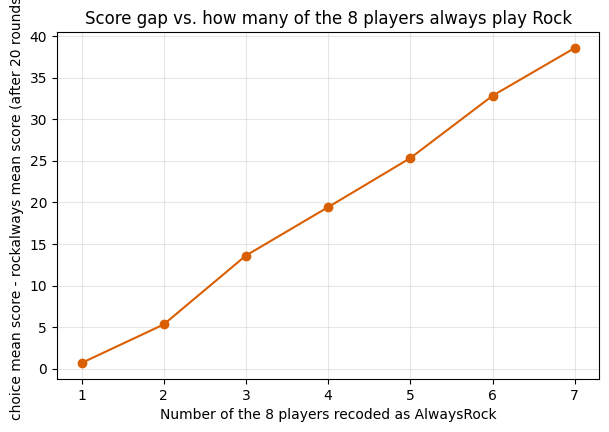

In [45]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(sweep_summary.index, sweep_summary['gap'], marker='o', color='#d95f02')

ax.set_xlabel('Number of the 8 players recoded as AlwaysRock')
ax.set_ylabel(f'choice mean score - rockalways mean score (after {rounds} rounds)')
ax.set_title('Score gap vs. how many of the 8 players always play Rock')
ax.grid(alpha=0.3)
plt.show()

The gap grows steadily as more of the eight players are recoded as `AlwaysRock` - from essentially nothing at `n_rocky = 1` to over 38 points at `n_rocky = 7`. The mechanism behind it is the same one Section 4.11 already found: every pair of `AlwaysRock` agents forces a 0-0 tie, so the more of them share the population, the more of their own games are wasted on each other, while the `choice` players' expected score per round stays roughly flat regardless of how many `AlwaysRock` agents they are facing.